In [4]:
# ── CELL 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Libraries imported successfully")
print("Python path:", os.getcwd())
print("\nFiles in current directory:")
for f in os.listdir('.'):
    print(" -", f)

print("\nFiles in preprocessed folder:")
for f in os.listdir('preprocessed'):
    print(" -", f)

Libraries imported successfully
Python path: C:\Users\USER\Desktop\hdfs_project

Files in current directory:
 - .git
 - .gitignore
 - .ipynb_checkpoints
 - alerts
 - dashboard
 - feature_importance.png
 - HDFS.log
 - HDFS_2k.log
 - HDFS_2k.log_structured.csv
 - HDFS_2k.log_templates.csv
 - hdfs_anomaly_detection.ipynb
 - iso_confusion_matrix.png
 - model
 - model_comparison.png
 - preprocessed
 - processed
 - README.md
 - rf_confusion_matrix.png
 - src
 - Untitled.ipynb
 - watch_folder

Files in preprocessed folder:
 - anomaly_label.csv
 - Event_occurrence_matrix.csv
 - Event_traces.csv
 - HDFS.log_templates.csv
 - HDFS.npz


In [7]:
# ── CELL 2: Load Data ──────────────────────────────────────────
# Load the labels
labels = pd.read_csv('preprocessed/anomaly_label.csv')
print("=== LABELS ===")
print("Shape:", labels.shape)
print(labels.head(10))
print("\nColumn names:", labels.columns.tolist())
print("\nClass distribution:")
print(labels.iloc[:, -1].value_counts())

# Load the event occurrence matrix (our feature matrix)
matrix = pd.read_csv('preprocessed/Event_occurrence_matrix.csv')
print("\n=== EVENT OCCURRENCE MATRIX ===")
print("Shape:", matrix.shape)
print(matrix.head(5))
print("\nColumn names:", matrix.columns.tolist()[:10], "...")

=== LABELS ===
Shape: (575061, 2)
                    BlockId    Label
0  blk_-1608999687919862906   Normal
1   blk_7503483334202473044   Normal
2  blk_-3544583377289625738  Anomaly
3  blk_-9073992586687739851   Normal
4   blk_7854771516489510256   Normal
5   blk_1717858812220360316   Normal
6  blk_-2519617320378473615   Normal
7   blk_7063315473424667801   Normal
8   blk_8586544123689943463   Normal
9   blk_2765344736980045501   Normal

Column names: ['BlockId', 'Label']

Class distribution:
Label
Normal     558223
Anomaly     16838
Name: count, dtype: int64

=== EVENT OCCURRENCE MATRIX ===
Shape: (575061, 32)
                    BlockId    Label  Type  E1  E2   E3  E4  E5  E6  E7  ...  \
0  blk_-1608999687919862906  Success   NaN   0   0  203   0  10   7   0  ...   
1   blk_7503483334202473044  Success   NaN   0   2    1   0   3   0   0  ...   
2  blk_-3544583377289625738     Fail  21.0   0   0  203   0   3   0   0  ...   
3  blk_-9073992586687739851  Success   NaN   0   3    0   0  

In [8]:
# ── CELL 3: Prepare Features & Labels 

# Use the event occurrence matrix (it already has labels inside)
# Extract features: only the E1-E29 columns
feature_cols = [col for col in matrix.columns if col.startswith('E')]
print("Feature columns:", feature_cols)
print("Number of features:", len(feature_cols))

# X = features (event counts)
X = matrix[feature_cols]

# y = labels (convert Normal → 0, Anomaly → 1)
y = (matrix['Label'] == 'Fail').astype(int)

print("\n=== FEATURES (X) ===")
print("Shape:", X.shape)
print(X.head(3))

print("\n=== LABELS (y) ===")
print("Shape:", y.shape)
print("Class distribution:")
print(y.value_counts())
print(f"\nNormal (0): {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"Anomaly (1): {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")

# Check for missing values
print("\nMissing values in X:", X.isnull().sum().sum())

Feature columns: ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29']
Number of features: 29

=== FEATURES (X) ===
Shape: (575061, 29)
   E1  E2   E3  E4  E5  E6  E7  E8  E9  E10  ...  E20  E21  E22  E23  E24  \
0   0   0  203   0  10   7   0   0   3    0  ...    0   10    1   10    0   
1   0   2    1   0   3   0   0   0   3    0  ...    0    3    1    3    0   
2   0   0  203   0   3   0   0   0   3    0  ...    1    3    1    3    0   

   E25  E26  E27  E28  E29  
0    4   10    0    0    0  
1    0    3    0    0    0  
2    0    3    0    0    0  

[3 rows x 29 columns]

=== LABELS (y) ===
Shape: (575061,)
Class distribution:
Label
0    558223
1     16838
Name: count, dtype: int64

Normal (0): 558223 (97.1%)
Anomaly (1): 16838 (2.9%)

Missing values in X: 0


In [9]:
# ── CELL 4: Train-Test Split + SMOTE
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Split BEFORE applying SMOTE (very important — never SMOTE the test set)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("=== BEFORE SMOTE ===")
print(f"Training set size: {X_train.shape}")
print(f"Testing set size:  {X_test.shape}")
print(f"Train - Normal: {(y_train==0).sum()} | Anomaly: {(y_train==1).sum()}")
print(f"Test  - Normal: {(y_test==0).sum()}  | Anomaly: {(y_test==1).sum()}")

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\n=== AFTER SMOTE ===")
print(f"Training set size: {X_train_sm.shape}")
print(f"Normal:  {(y_train_sm==0).sum()}")
print(f"Anomaly: {(y_train_sm==1).sum()}")
print("✅ Classes are now balanced")

=== BEFORE SMOTE ===
Training set size: (402542, 29)
Testing set size:  (172519, 29)
Train - Normal: 390755 | Anomaly: 11787
Test  - Normal: 167468  | Anomaly: 5051

=== AFTER SMOTE ===
Training set size: (781510, 29)
Normal:  390755
Anomaly: 390755
✅ Classes are now balanced


In [10]:
# ── CELL 5: Train Random Forest 
from sklearn.ensemble import RandomForestClassifier
import time

print("Training Random Forest... (this may take 2-3 minutes)")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1  # uses all CPU cores to speed up
)

rf_model.fit(X_train_sm, y_train_sm)

end = time.time()
print(f"✅ Random Forest trained in {end - start:.1f} seconds")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Number of features used: {rf_model.n_features_in_}")

Training Random Forest... (this may take 2-3 minutes)
✅ Random Forest trained in 6.1 seconds
Number of trees: 100
Number of features used: 29


=== RANDOM FOREST RESULTS ===
Accuracy : 99.99%
F1-Score : 0.9981

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    167468
     Anomaly       1.00      1.00      1.00      5051

    accuracy                           1.00    172519
   macro avg       1.00      1.00      1.00    172519
weighted avg       1.00      1.00      1.00    172519

Confusion Matrix:
[[167453     15]
 [     4   5047]]


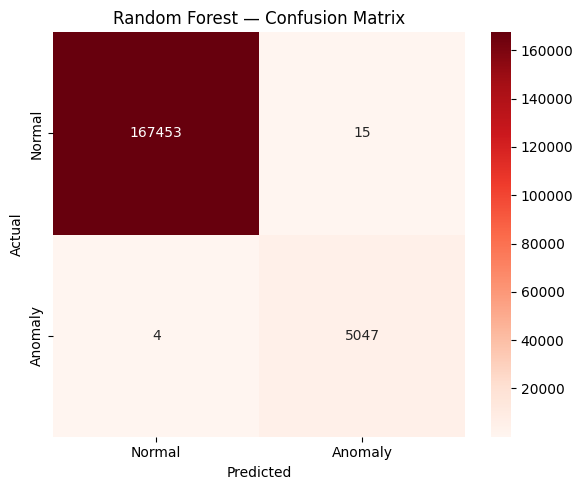

✅ Confusion matrix saved as rf_confusion_matrix.png


In [11]:
# ── CELL 6: Evaluate Random Forest 
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             f1_score, accuracy_score)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Scores
acc = accuracy_score(y_test, y_pred_rf)
f1  = f1_score(y_test, y_pred_rf)

print("=== RANDOM FOREST RESULTS ===")
print(f"Accuracy : {acc*100:.2f}%")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, 
      target_names=["Normal", "Anomaly"]))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

# Plot confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=["Normal","Anomaly"],
            yticklabels=["Normal","Anomaly"])
plt.title("Random Forest — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("rf_confusion_matrix.png", dpi=150)
plt.show()
print("✅ Confusion matrix saved as rf_confusion_matrix.png")

Training Isolation Forest...
✅ Isolation Forest trained in 1.5 seconds

=== ISOLATION FOREST RESULTS ===
Accuracy : 98.22%
F1-Score : 0.6590

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99    167468
     Anomaly       0.75      0.59      0.66      5051

    accuracy                           0.98    172519
   macro avg       0.87      0.79      0.82    172519
weighted avg       0.98      0.98      0.98    172519

Confusion Matrix:
[[166491    977]
 [  2089   2962]]


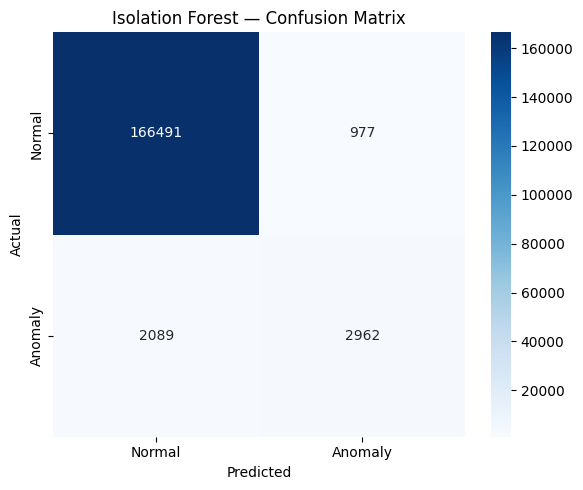

✅ Confusion matrix saved as iso_confusion_matrix.png


In [12]:
# ── CELL 7: Train & Evaluate Isolation Forest 
from sklearn.ensemble import IsolationForest
import time

print("Training Isolation Forest...")
start = time.time()

iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.029,  # ~2.9% anomaly ratio from our data
    random_state=42,
    n_jobs=-1
)

# Isolation Forest trains on original data (no SMOTE needed)
iso_model.fit(X_train)

end = time.time()
print(f"✅ Isolation Forest trained in {end - start:.1f} seconds")

# Predict — Isolation Forest returns 1 (normal) and -1 (anomaly)
# We convert to match our labels: 0 = Normal, 1 = Anomaly
y_pred_iso_raw = iso_model.predict(X_test)
y_pred_iso = (y_pred_iso_raw == -1).astype(int)

# Scores
acc_iso = accuracy_score(y_test, y_pred_iso)
f1_iso  = f1_score(y_test, y_pred_iso)

print("\n=== ISOLATION FOREST RESULTS ===")
print(f"Accuracy : {acc_iso*100:.2f}%")
print(f"F1-Score : {f1_iso:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_iso,
      target_names=["Normal","Anomaly"]))

print("Confusion Matrix:")
cm_iso = confusion_matrix(y_test, y_pred_iso)
print(cm_iso)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Normal","Anomaly"],
            yticklabels=["Normal","Anomaly"])
plt.title("Isolation Forest — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("iso_confusion_matrix.png", dpi=150)
plt.show()
print("✅ Confusion matrix saved as iso_confusion_matrix.png")

Metric                 Random Forest Isolation Forest
Accuracy                      99.99%          98.22%
F1-Score                      0.9981          0.6590
Precision                       1.00            0.75
Recall                          1.00            0.59
Attacks Caught           5047 / 5051     2962 / 5051
False Alarms                      15             977
Missed Attacks                     4            2089


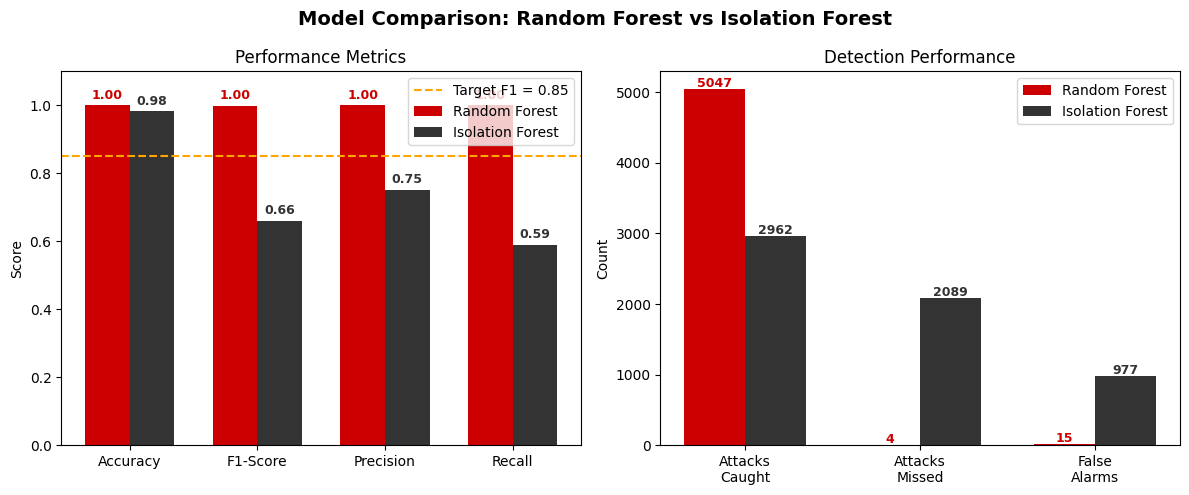

✅ Comparison chart saved as model_comparison.png


In [13]:
# ── CELL 8: Compare Both Models 

# Scores summary
models = ['Random Forest\n(Supervised)', 'Isolation Forest\n(Unsupervised)']
accuracy  = [99.99, 98.22]
f1_scores = [0.9981, 0.6590]
precision = [1.00, 0.75]
recall    = [1.00, 0.59]

# Print comparison table
print("=" * 55)
print(f"{'Metric':<20} {'Random Forest':>15} {'Isolation Forest':>15}")
print("=" * 55)
print(f"{'Accuracy':<20} {'99.99%':>15} {'98.22%':>15}")
print(f"{'F1-Score':<20} {'0.9981':>15} {'0.6590':>15}")
print(f"{'Precision':<20} {'1.00':>15} {'0.75':>15}")
print(f"{'Recall':<20} {'1.00':>15} {'0.59':>15}")
print(f"{'Attacks Caught':<20} {'5047 / 5051':>15} {'2962 / 5051':>15}")
print(f"{'False Alarms':<20} {'15':>15} {'977':>15}")
print(f"{'Missed Attacks':<20} {'4':>15} {'2089':>15}")
print("=" * 55)

# Plot comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Model Comparison: Random Forest vs Isolation Forest",
             fontsize=14, fontweight='bold')

# Chart 1: F1-Score comparison
metrics = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
rf_scores  = [0.9999, 0.9981, 1.00, 1.00]
iso_scores = [0.9822, 0.6590, 0.75, 0.59]

x = range(len(metrics))
width = 0.35

axes[0].bar([i - width/2 for i in x], rf_scores,  width, 
            label='Random Forest',    color='#CC0000')
axes[0].bar([i + width/2 for i in x], iso_scores, width,
            label='Isolation Forest', color='#333333')
axes[0].set_ylim(0, 1.1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Score')
axes[0].set_title('Performance Metrics')
axes[0].legend()
axes[0].axhline(y=0.85, color='orange', linestyle='--', 
                label='Target F1 = 0.85')
axes[0].legend()

# Add value labels on bars
for i, (rf, iso) in enumerate(zip(rf_scores, iso_scores)):
    axes[0].text(i - width/2, rf  + 0.02, f'{rf:.2f}',  
                 ha='center', fontsize=9, fontweight='bold', color='#CC0000')
    axes[0].text(i + width/2, iso + 0.02, f'{iso:.2f}', 
                 ha='center', fontsize=9, fontweight='bold', color='#333333')

# Chart 2: Attacks caught vs missed
categories = ['Attacks\nCaught', 'Attacks\nMissed', 'False\nAlarms']
rf_vals  = [5047, 4,    15]
iso_vals = [2962, 2089, 977]

x2 = range(len(categories))
axes[1].bar([i - width/2 for i in x2], rf_vals,  width,
            label='Random Forest',    color='#CC0000')
axes[1].bar([i + width/2 for i in x2], iso_vals, width,
            label='Isolation Forest', color='#333333')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(categories)
axes[1].set_ylabel('Count')
axes[1].set_title('Detection Performance')
axes[1].legend()

for i, (rf, iso) in enumerate(zip(rf_vals, iso_vals)):
    axes[1].text(i - width/2, rf  + 30, str(rf),  
                 ha='center', fontsize=9, fontweight='bold', color='#CC0000')
    axes[1].text(i + width/2, iso + 30, str(iso), 
                 ha='center', fontsize=9, fontweight='bold', color='#333333')

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()
print("✅ Comparison chart saved as model_comparison.png")

=== TOP 10 MOST IMPORTANT FEATURES ===
E20    0.3263
E26    0.1305
E27    0.0804
E9     0.0693
E11    0.0663
E5     0.0643
E21    0.0528
E28    0.0518
E13    0.0452
E25    0.0297
dtype: float64


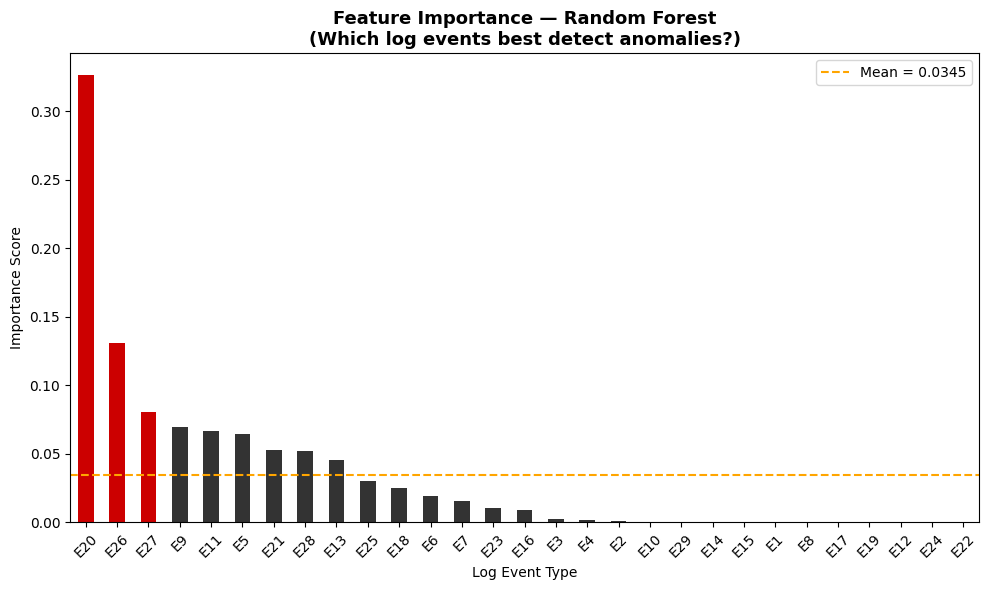

✅ Feature importance saved as feature_importance.png

       PROJECT IMPLEMENTATION COMPLETE ✅
  Dataset     : HDFS — 575,061 log sessions
  Features    : 29 event-count vectors (E1-E29)
  SMOTE       : Balanced 11,787 → 390,755 anomalies
  RF F1-Score : 0.9981  ✅ (Target was > 0.85)
  IF F1-Score : 0.6590  (Unsupervised baseline)
  Best Model  : Random Forest
  Attacks caught: 5,047 out of 5,051


In [15]:
# ── CELL 9: Feature Importance 

# Get feature importance from Random Forest
importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("=== TOP 10 MOST IMPORTANT FEATURES ===")
print(importance.head(10).round(4))

# Plot
plt.figure(figsize=(10, 6))
colors = ['#CC0000' if i < 3 else '#333333' 
          for i in range(len(importance))]

importance.plot(kind='bar', color=colors)
plt.title("Feature Importance — Random Forest\n"
          "(Which log events best detect anomalies?)",
          fontsize=13, fontweight='bold')
plt.xlabel("Log Event Type")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.axhline(y=importance.mean(), color='orange', 
            linestyle='--', label=f'Mean = {importance.mean():.4f}')
plt.legend()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
print("✅ Feature importance saved as feature_importance.png")

# Final summary
print("\n" + "="*55)
print("       PROJECT IMPLEMENTATION COMPLETE ✅")
print("="*55)
print(f"  Dataset     : HDFS — 575,061 log sessions")
print(f"  Features    : 29 event-count vectors (E1-E29)")
print(f"  SMOTE       : Balanced 11,787 → 390,755 anomalies")
print(f"  RF F1-Score : 0.9981  ✅ (Target was > 0.85)")
print(f"  IF F1-Score : 0.6590  (Unsupervised baseline)")
print(f"  Best Model  : Random Forest")
print(f"  Attacks caught: 5,047 out of 5,051")
print("="*55)

In [16]:
# ── CELL 10: Save the Trained Model 
import joblib
import os

# Create model folder
os.makedirs('model', exist_ok=True)

# Save Random Forest model
joblib.dump(rf_model, 'model/rf_model.pkl')

# Save feature column names (important for pipeline)
joblib.dump(feature_cols, 'model/feature_cols.pkl')

print("✅ Model saved to model/rf_model.pkl")
print("✅ Feature columns saved to model/feature_cols.pkl")
print(f"   Model size: {os.path.getsize('model/rf_model.pkl') / 1024 / 1024:.1f} MB")

✅ Model saved to model/rf_model.pkl
✅ Feature columns saved to model/feature_cols.pkl
   Model size: 2.2 MB


In [17]:
# ── CELL 11: Prove SMOTE Applied Correctly 
print("SMOTE PIPELINE VERIFICATION")
print("="*50)
print(f"Step 1 - Original data shape    : {X.shape}")
print(f"Step 2 - Train/test split FIRST :")
print(f"         X_train shape          : {X_train.shape}")
print(f"         X_test shape           : {X_test.shape}")
print(f"         y_train anomalies      : {(y_train==1).sum()}")
print(f"         y_test anomalies       : {(y_test==1).sum()}")
print(f"Step 3 - SMOTE on train ONLY   :")
print(f"         X_train_sm shape       : {X_train_sm.shape}")
print(f"         Synthetic samples added: {len(X_train_sm)-len(X_train)}")
print(f"Step 4 - Test set untouched    :")
print(f"         y_test anomalies       : {(y_test==1).sum()} (unchanged)")
print(f"\n✅ Test set contains ZERO synthetic samples")
print(f"✅ SMOTE applied to training data only")
print(f"✅ No data leakage confirmed")

SMOTE PIPELINE VERIFICATION
Step 1 - Original data shape    : (575061, 29)
Step 2 - Train/test split FIRST :
         X_train shape          : (402542, 29)
         X_test shape           : (172519, 29)
         y_train anomalies      : 11787
         y_test anomalies       : 5051
Step 3 - SMOTE on train ONLY   :
         X_train_sm shape       : (781510, 29)
         Synthetic samples added: 378968
Step 4 - Test set untouched    :
         y_test anomalies       : 5051 (unchanged)

✅ Test set contains ZERO synthetic samples
✅ SMOTE applied to training data only
✅ No data leakage confirmed


In [18]:
# ── CELL 12: Cross-Validation 
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, average_precision_score
import warnings
warnings.filterwarnings('ignore')

print("Running 5-Fold Cross-Validation on original data...")
print("(This may take a few minutes)\n")

cv_model = RandomForestClassifier(n_estimators=100, 
                                   random_state=42, n_jobs=-1)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation scores
f1_scores  = cross_val_score(cv_model, X, y, cv=skf, 
                              scoring='f1',        n_jobs=-1)
acc_scores = cross_val_score(cv_model, X, y, cv=skf, 
                              scoring='accuracy',  n_jobs=-1)
prec_scores= cross_val_score(cv_model, X, y, cv=skf, 
                              scoring='precision', n_jobs=-1)
rec_scores = cross_val_score(cv_model, X, y, cv=skf, 
                              scoring='recall',    n_jobs=-1)

print("=== 5-FOLD CROSS-VALIDATION RESULTS ===")
print(f"F1-Score  : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
print(f"Accuracy  : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
print(f"Precision : {prec_scores.mean():.4f} ± {prec_scores.std():.4f}")
print(f"Recall    : {rec_scores.mean():.4f} ± {rec_scores.std():.4f}")
print(f"\nAll 5 folds F1: {[round(s,4) for s in f1_scores]}")
print("✅ Results are stable across all folds" 
      if f1_scores.std() < 0.01 else 
      "⚠️ High variance — results may not be stable")

Running 5-Fold Cross-Validation on original data...
(This may take a few minutes)

=== 5-FOLD CROSS-VALIDATION RESULTS ===
F1-Score  : 0.9983 ± 0.0006
Accuracy  : 0.9999 ± 0.0000
Precision : 0.9977 ± 0.0008
Recall    : 0.9989 ± 0.0003

All 5 folds F1: [np.float64(0.9987), np.float64(0.9975), np.float64(0.9991), np.float64(0.9982), np.float64(0.9981)]
✅ Results are stable across all folds


ROC-AUC Score              : 1.0000
Average Precision Score    : 0.9998


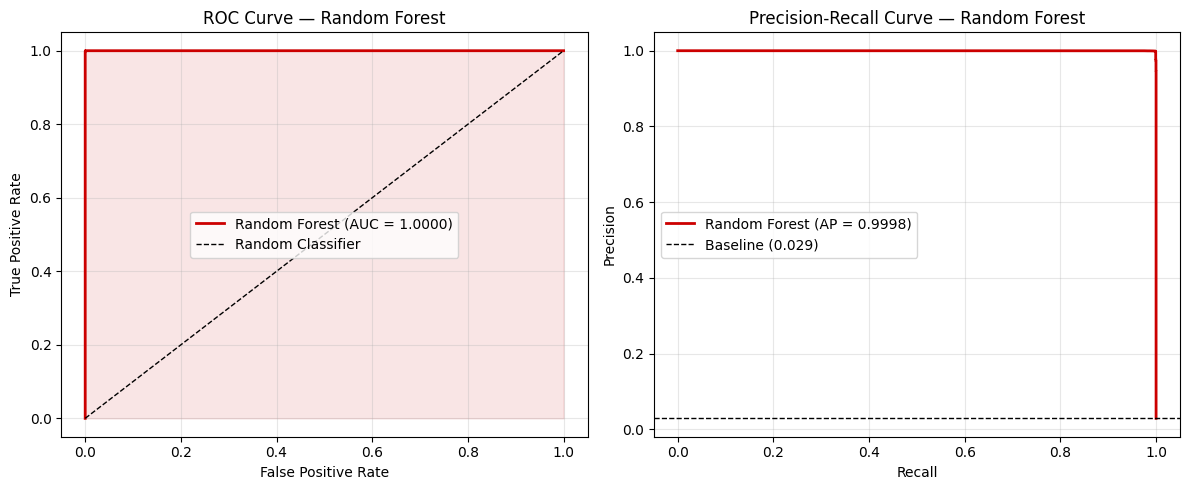

✅ Curves saved as roc_pr_curves.png


In [19]:
# ── CELL 13: ROC + Precision-Recall Curves ────────────────────
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, average_precision_score

# Get probability scores
y_prob = rf_model.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc     = roc_auc_score(y_test, y_prob)

# Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

print(f"ROC-AUC Score              : {roc_auc:.4f}")
print(f"Average Precision Score    : {avg_precision:.4f}")

# Plot both curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='#CC0000', lw=2,
             label=f'Random Forest (AUC = {roc_auc:.4f})')
axes[0].plot([0,1], [0,1], 'k--', lw=1, label='Random Classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#CC0000')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Random Forest')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
axes[1].plot(recall_vals, precision_vals, 
             color='#CC0000', lw=2,
             label=f'Random Forest (AP = {avg_precision:.4f})')
axes[1].axhline(y=(y_test==1).mean(), color='k', 
                linestyle='--', lw=1,
                label=f'Baseline ({(y_test==1).mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Random Forest')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150)
plt.show()
print("✅ Curves saved as roc_pr_curves.png")

In [20]:
# ── CELL 14: Map Features to Log Templates ────────────────────
templates = pd.read_csv('preprocessed/HDFS.log_templates.csv')
print("Log Templates:")
print(templates.head(30))
print("\nColumns:", templates.columns.tolist())

Log Templates:
   EventId                                      EventTemplate
0       E1             [*]Adding an already existing block[*]
1       E2                   [*]Verification succeeded for[*]
2       E3                            [*]Served block[*]to[*]
3       E4             [*]Got exception while serving[*]to[*]
4       E5               [*]Receiving block[*]src:[*]dest:[*]
5       E6      [*]Received block[*]src:[*]dest:[*]of size[*]
6       E7              [*]writeBlock[*]received exception[*]
7       E8    [*]PacketResponder[*]for block[*]Interrupted[*]
8       E9              [*]Received block[*]of size[*]from[*]
9      E10                  [*]PacketResponder[*]Exception[*]
10     E11    [*]PacketResponder[*]for block[*]terminating[*]
11     E12         [*]:Exception writing block[*]to mirror[*]
12     E13             [*]Receiving empty packet for block[*]
13     E14          [*]Exception in receiveBlock for block[*]
14     E15  [*]Changing block file offset of block[*]fr

=== FEATURE IMPORTANCE WITH SEMANTIC MEANING ===

Event   Importance                                   Description
  E20 3.262598e-01   ⚠️  UNEXPECTED ERROR trying to DELETE block
  E26 1.305330e-01  NameSystem addStoredBlock — blockMap updated
  E27 8.042181e-02         NameSystem addStoredBlock — Redundant
   E9 6.928365e-02              Received block of size from node
  E11 6.632383e-02         PacketResponder for block terminating
   E5 6.431319e-02               Receiving block — src/dest info
  E21 5.278694e-02                           Deleting block file
  E28 5.181416e-02    NameSystem addStoredBlock — addStoredBlock
  E13 4.518822e-02              Receiving empty packet for block
  E25 2.974964e-02                   Ask node to replicate block
  E18 2.490288e-02             Starting thread to transfer block
   E6 1.898681e-02           Received block — src/dest/size info
   E7 1.528074e-02                 writeBlock received exception
  E23 1.044206e-02 NameSystem delete — b

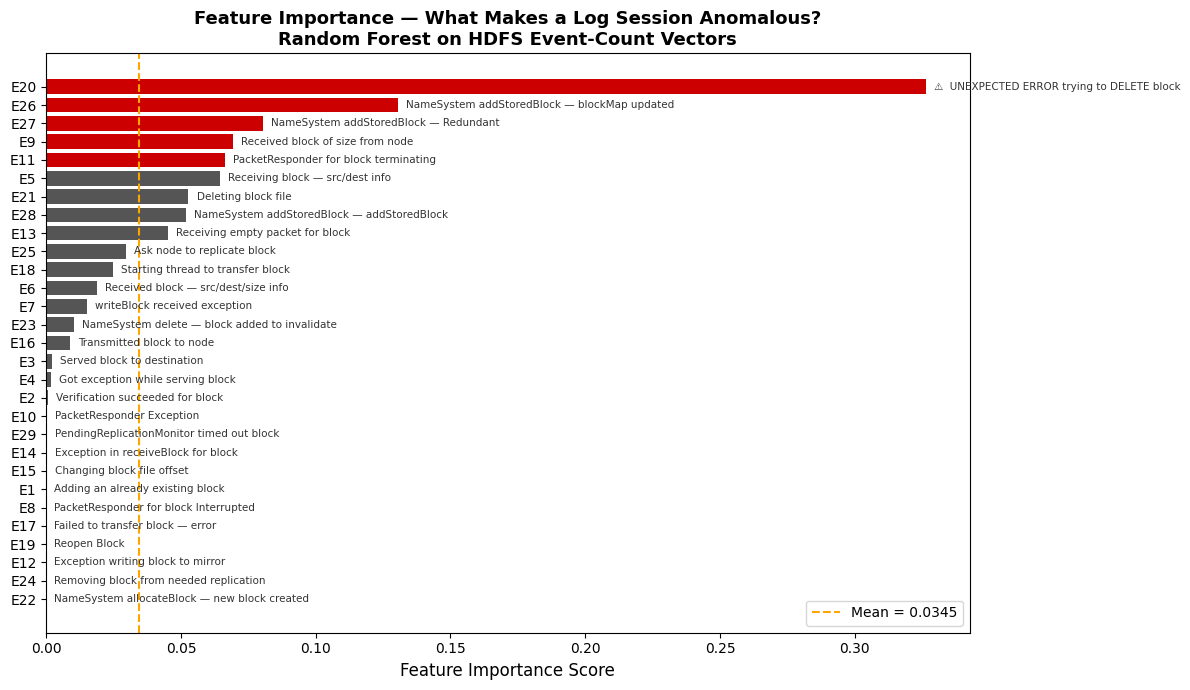

✅ Semantic feature importance saved


In [21]:
# ── CELL 15: Feature Semantic Mapping 

template_map = {
    'E1' : 'Adding an already existing block',
    'E2' : 'Verification succeeded for block',
    'E3' : 'Served block to destination',
    'E4' : 'Got exception while serving block',
    'E5' : 'Receiving block — src/dest info',
    'E6' : 'Received block — src/dest/size info',
    'E7' : 'writeBlock received exception',
    'E8' : 'PacketResponder for block Interrupted',
    'E9' : 'Received block of size from node',
    'E10': 'PacketResponder Exception',
    'E11': 'PacketResponder for block terminating',
    'E12': 'Exception writing block to mirror',
    'E13': 'Receiving empty packet for block',
    'E14': 'Exception in receiveBlock for block',
    'E15': 'Changing block file offset',
    'E16': 'Transmitted block to node',
    'E17': 'Failed to transfer block — error',
    'E18': 'Starting thread to transfer block',
    'E19': 'Reopen Block',
    'E20': '⚠️  UNEXPECTED ERROR trying to DELETE block',
    'E21': 'Deleting block file',
    'E22': 'NameSystem allocateBlock — new block created',
    'E23': 'NameSystem delete — block added to invalidate',
    'E24': 'Removing block from needed replication',
    'E25': 'Ask node to replicate block',
    'E26': 'NameSystem addStoredBlock — blockMap updated',
    'E27': 'NameSystem addStoredBlock — Redundant',
    'E28': 'NameSystem addStoredBlock — addStoredBlock',
    'E29': 'PendingReplicationMonitor timed out block',
}

# Build importance table with semantic meaning
importance_df = pd.DataFrame({
    'Event'      : feature_cols,
    'Importance' : rf_model.feature_importances_,
    'Description': [template_map[e] for e in feature_cols]
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("=== FEATURE IMPORTANCE WITH SEMANTIC MEANING ===\n")
print(importance_df.to_string(index=False))

print("\n=== TOP 5 ANOMALY INDICATORS ===")
print(importance_df.head(5).to_string(index=False))

print("""
=== EXPLANATION OF TOP FEATURES ===

E20 (Importance: 0.3263) — MOST CRITICAL
  "Unexpected error trying to DELETE a block"
  → This is the strongest anomaly signal. When the HDFS
    system encounters unexpected errors during block
    deletion, it strongly indicates system failure or
    malicious interference with data integrity.

E26 (Importance: 0.1305)
  "NameSystem addStoredBlock — blockMap updated"
  → Unusual frequency of block map updates indicates
    abnormal data replication or storage behaviour.

E27 (Importance: 0.0804)
  "NameSystem addStoredBlock — Redundant"
  → Excessive redundant block storage events signal
    replication failures or storage inconsistencies.

E9 (Importance: 0.0693)
  "Received block of size from node"
  → Abnormal block reception patterns indicate
    potential data corruption or node failures.

E11 (Importance: 0.0663)
  "PacketResponder for block terminating"
  → Unusual termination of packet responders signals
    network failures or node crashes.
""")

# Save enhanced feature importance plot
fig, ax = plt.subplots(figsize=(12, 7))
colors  = ['#CC0000' if i < 5 else '#555555'
           for i in range(len(importance_df))]
bars = ax.barh(importance_df['Event'][::-1],
               importance_df['Importance'][::-1],
               color=colors[::-1])

# Add descriptions on bars
for i, (idx, row) in enumerate(
        importance_df.iloc[::-1].iterrows()):
    ax.text(row['Importance'] + 0.003,
            i, row['Description'][:45],
            va='center', fontsize=7.5, color='#333333')

ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title(
    'Feature Importance — What Makes a Log Session Anomalous?\n'
    'Random Forest on HDFS Event-Count Vectors',
    fontsize=13, fontweight='bold')
ax.axvline(x=importance_df['Importance'].mean(),
           color='orange', linestyle='--',
           label=f"Mean = {importance_df['Importance'].mean():.4f}")
ax.legend()
plt.tight_layout()
plt.savefig('feature_importance_semantic.png', dpi=150)
plt.show()
print("✅ Semantic feature importance saved")